# Adult Census Income Classification

## Problem Statement
Predict whether an adult's annual income exceeds $50K using demographic and employment attributes.

## Dataset Description
UCI Adult / Census Income, retrieved from OpenML with an HTTPS UCI fallback. The target is `class`; the data contain mixed numeric and categorical fields and a class imbalance.

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
from sklearn.datasets import fetch_openml
try:
    adult = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
    raw_data = adult.frame.copy()
except Exception:
    columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "class"]
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    raw_data = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)
raw_data.columns = [str(c).replace("_", "-") for c in raw_data.columns]
target_column = "class"
raw_data[target_column] = raw_data[target_column].astype(str).str.replace(".", "", regex=False).str.strip().eq(">50K").astype(int)
raw_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


## Data Inspection & Cleaning

In [3]:
data = raw_data.replace("?", np.nan).drop_duplicates().copy()
print(data.shape)
display(data.dtypes.to_frame("dtype").T)
display(data.isna().mean().sort_values(ascending=False).head(10).to_frame("missing share"))

(48790, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
dtype,int64,category,int64,category,int64,category,category,category,category,category,int64,int64,int64,category,int64


,missing share
occupation,0.057491
workclass,0.057286
native-country,0.017545
fnlwgt,0.000000
education,0.000000
education-num,0.000000
age,0.000000
marital-status,0.000000
relationship,0.000000
sex,0.000000


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

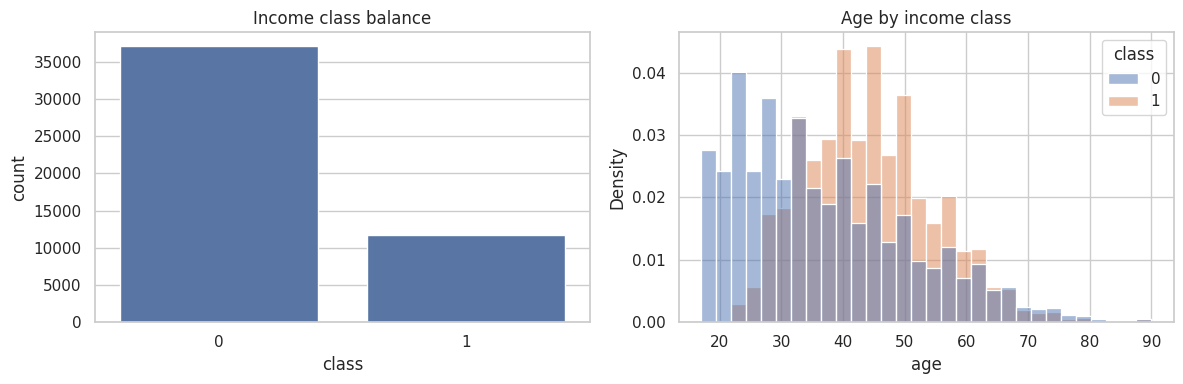

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=data, x=target_column, ax=axes[0]); axes[0].set_title("Income class balance")
sns.histplot(data=data, x="age", hue=target_column, bins=30, stat="density", common_norm=False, ax=axes[1]); axes[1].set_title("Age by income class")
plt.tight_layout()

## Feature Engineering

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features = data.drop(columns=target_column)
labels = data[target_column]
numeric_features = features.select_dtypes(include=np.number).columns
categorical_features = features.select_dtypes(exclude=np.number).columns
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, stratify=labels, random_state=SEED)

## Model Development

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

baseline = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=500, class_weight="balanced"))])
baseline.fit(X_train, y_train)
baseline_score = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])

# One-hot encoding is sparse; a random forest provides a robust nonlinear comparison.
from sklearn.ensemble import RandomForestClassifier
forest = Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", random_state=SEED, n_jobs=-1))])
forest.fit(X_train, y_train)
forest_score = roc_auc_score(y_test, forest.predict_proba(X_test)[:, 1])
print({"logistic ROC-AUC": baseline_score, "random forest ROC-AUC": forest_score})

{'logistic ROC-AUC': np.float64(0.9021745675573914), 'random forest ROC-AUC': np.float64(0.9149171647693085)}


## Hyperparameter Tuning

In [8]:
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(forest, {"model__max_depth": [None, 12, 20], "model__max_features": ["sqrt", 0.5]}, n_iter=4, scoring="roc_auc", cv=3, random_state=SEED, n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best CV ROC-AUC:", search.best_score_)

Best CV ROC-AUC: 0.9158385703357229


## Evaluation

In [9]:
predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, predictions, digits=3))
print("Test ROC-AUC:", roc_auc_score(y_test, probabilities))

              precision    recall  f1-score   support

           0      0.933     0.845     0.887      7422
           1      0.620     0.806     0.701      2336

    accuracy                          0.836      9758
   macro avg      0.777     0.825     0.794      9758
weighted avg      0.858     0.836     0.842      9758

Test ROC-AUC: 0.9146714587416899


## Visualizations

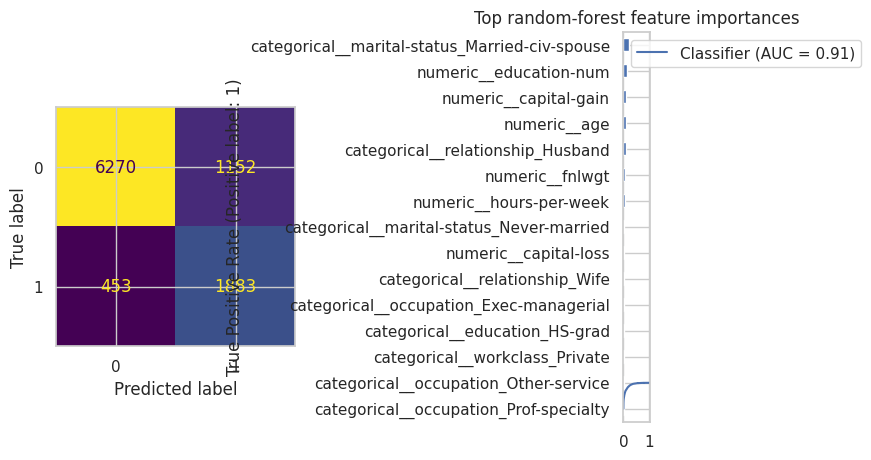

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, probabilities, ax=axes[1])
plt.tight_layout()
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importance = pd.Series(best_model.named_steps["model"].feature_importances_, index=feature_names).nlargest(15).sort_values()
importance.plot.barh(figsize=(8, 5), title="Top random-forest feature importances"); plt.tight_layout()

## Prediction Examples

In [11]:
examples = X_test.head(8).copy()
examples["predicted_probability"] = probabilities[:8]
examples["actual_income_over_50k"] = y_test.iloc[:8].to_numpy()
display(examples[["age", "education", "occupation", "hours-per-week", "predicted_probability", "actual_income_over_50k"]])

,age,education,occupation,hours-per-week,predicted_probability,actual_income_over_50k
30204,34,HS-grad,Other-service,40,0.010434,0
26624,39,Bachelors,Craft-repair,60,0.236780,0
17977,49,HS-grad,Exec-managerial,43,0.591906,0
20164,63,10th,Machine-op-inspct,40,0.136313,0
10557,34,Some-college,Exec-managerial,45,0.502821,1
24006,53,HS-grad,Machine-op-inspct,50,0.290946,0
39208,25,Some-college,Tech-support,40,0.031485,0
23149,32,HS-grad,Other-service,20,0.000316,0


## Discussion
The nonlinear model captures interactions between education, occupation, capital gains, and hours worked. Threshold selection should reflect the cost of each error; demographic proxies also warrant a fairness assessment before real-world use.

## Conclusion
The comparison establishes a transparent linear baseline and a stronger nonlinear alternative, evaluated with class-aware metrics and feature-level inspection.